# N25C — Final TEST evaluation of the risk-weighted frozen application

This notebook evaluates, without refitting or retuning, the outcome-free N24C risk-weighted specification on the final TEST chronology. It is a model-valued approximately 24-hour USD/JPY ATM-straddle strategy evaluation, not an executable historical OTC-options backtest. Hidden states denote hidden abnormal-response states.

In [1]:
from pathlib import Path
import ast, hashlib, json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
from IPython.display import display, Markdown

PROJECT = Path.cwd()
if not (PROJECT / 'Data' / 'processed').exists():
    PROJECT = Path(r"C:\Users\Rajiv Nawal\OneDrive\Documents\GITREPOS\HSBC-AN-RN\CODEWORK\Linus' Task Re-Do")
PROCESSED = PROJECT / 'Data' / 'processed'
FIGURES = PROJECT / 'figures'
FIGURES.mkdir(exist_ok=True)
assert PROCESSED.exists(), f'Missing processed directory: {PROCESSED}'

def sha256(path):
    return hashlib.sha256(Path(path).read_bytes()).hexdigest()

handoff_path = PROCESSED / '24C_test_prediction_policy_handoff.csv'
spec_path = PROCESSED / '24C_frozen_application_specification.csv'
refit_path = PROCESSED / '24C_final_refit_manifest.csv'
availability_path = PROCESSED / '24C_test_feature_availability_audit.csv'
pretest_path = PROCESSED / '24C_application_common_feature_panel_pretest.csv'
for p in [handoff_path, spec_path, refit_path, availability_path, pretest_path]:
    assert p.exists(), f'Required frozen N24C input missing: {p.name}'

n24c_hashes_before = {p.name: sha256(p) for p in [handoff_path, spec_path, refit_path, availability_path, pretest_path]}
handoff = pd.read_csv(handoff_path, parse_dates=['decision_model_day', 'forecast_target_model_day'])
spec = pd.read_csv(spec_path)
assert len(spec) == 1, 'Frozen N24C specification must have exactly one row.'
spec_row = spec.iloc[0]
required_handoff = {'decision_model_day','forecast_target_model_day','stage','G_t','c_entry_L','c_entry_S','R_model_support','I_model_support','Yhat_BASE','Yhat_HIDDEN_AWARE','Yhat_NOISE_19','Yhat_NOISE_119','Yhat_NOISE_219','z_BASE','z_GATE_ONLY','z_HIDDEN_RAW','z_HIDDEN_AWARE'}
assert required_handoff.issubset(handoff.columns), f'Missing frozen handoff columns: {sorted(required_handoff-set(handoff.columns))}'
assert not {'Y_gross','Y_net_L','Y_net_S'}.intersection(handoff.columns), 'N24C handoff must remain outcome-free before audit.'
assert len(handoff) == 901 and handoff['stage'].eq('TEST').all(), 'Unexpected N24C TEST handoff chronology.'
assert handoff['decision_model_day'].is_unique and handoff['forecast_target_model_day'].is_unique, 'Frozen handoff key is not one-to-one.'
assert spec_row['objective'] == 'MAXIMISE_VALIDATION_RISK_WEIGHTED_NET_PNL_J'
assert int(spec_row['minimum_validation_trades']) == 30
assert spec_row['GB_internal_loss'] == 'squared_error'
assert int(spec_row['support_floor']) == 3
assert int(spec_row['selected_candidate_id']) == 16
params = ast.literal_eval(spec_row['selected_hyperparameters'])
assert {k: params[k] for k in ['n_estimators','learning_rate','max_depth','min_samples_leaf']} == {'n_estimators':250,'learning_rate':0.05,'max_depth':2,'min_samples_leaf':40}
assert params['loss'] == 'squared_error'
assert set(ast.literal_eval('[' + spec_row['noise_seeds'].replace(' | ', ',') + ']')) == {19,119,219}
assert handoff['G_t'].isin([0,1]).all() and int(handoff['G_t'].sum()) == 74
assert (handoff['R_model_support'] >= 3).all() and (handoff['I_model_support'] >= 3).all()
assert (handoff['z_GATE_ONLY'].astype(int) == handoff['z_BASE'].astype(int) * handoff['G_t'].astype(int)).all()
assert (handoff.loc[handoff['G_t'].eq(0), 'z_HIDDEN_AWARE'].eq(0)).all()
assert handoff[['Yhat_BASE','Yhat_HIDDEN_AWARE','Yhat_NOISE_19','Yhat_NOISE_119','Yhat_NOISE_219']].apply(np.isfinite).all().all()
refit = pd.read_csv(refit_path)
availability = pd.read_csv(availability_path)
assert int(refit.loc[0, 'refit_rows']) == 1707 and int(refit.loc[0, 'selected_candidate_id']) == 16
assert int(availability.loc[availability['stage'].eq('TEST'), 'COMMON_complete'].iloc[0]) == 901
assert int(availability.loc[availability['stage'].eq('TEST'), 'gate_entries_surviving_COMMON'].iloc[0]) == 74
pretest = pd.read_csv(pretest_path)
assert set(pretest['stage']) == {'C','VALIDATION'} and 'Y_gross' in pretest.columns
cvalidation_mean_forecast = float(pretest['Y_gross'].mean())
handoff_snapshot = handoff.copy(deep=True)
# This correction may change only the supporting gate-timing regression.
# Snapshot previously accepted primary N25C results before TEST outcomes are opened.
primary_reference_paths = {
    'predictive': PROCESSED / '25C_test_predictive_metrics.csv',
    'economics': PROCESSED / '25C_test_economic_metrics.csv',
    'actions': PROCESSED / '25C_test_policy_action_counts.csv',
    'hidden_incremental': PROCESSED / '25C_test_hidden_incremental_diagnostic.csv',
}
assert all(p.exists() for p in primary_reference_paths.values()), 'Prior accepted N25C primary-result snapshots are required for this surgical correction.'
primary_reference = {name: pd.read_csv(path) for name, path in primary_reference_paths.items()}
figure_paths = [FIGURES / name for name in ['25C_test_cumulative_net_pnl.png','25C_test_predictive_mse_comparison.png','25C_test_risk_weighted_J_comparison.png']]
assert all(p.exists() for p in figure_paths), 'Existing accepted N25C figures are required for invariance verification.'
figure_hashes_before = {p.name: sha256(p) for p in figure_paths}
print('N25C pre-outcome freeze audit: PASS')
print('No model or policy choice will be changed after TEST outcomes are merged.')
display(pd.DataFrame([{
    'selected_candidate_id': int(spec_row['selected_candidate_id']), 'frozen_hyperparameters': str(params),
    'minimum_validation_trades': int(spec_row['minimum_validation_trades']), 'support_floor': int(spec_row['support_floor']),
    'C_VALIDATION_refit_rows': int(refit.loc[0, 'refit_rows']), 'TEST_handoff_rows': len(handoff),
    'TEST_gate_rows': int(handoff['G_t'].sum()), 'BASE_features': spec_row['BASE_features'],
    'HIDDEN_features': spec_row['HIDDEN_features'], 'gate_rule': spec_row['gate'], 'action_rule': spec_row['action_mapping']
}]))


N25C pre-outcome freeze audit: PASS
No model or policy choice will be changed after TEST outcomes are merged.


,selected_candidate_id,frozen_hyperparameters,minimum_validation_trades,support_floor,C_VALIDATION_refit_rows,TEST_handoff_rows,TEST_gate_rows,BASE_features,HIDDEN_features,gate_rule,action_rule
0,16,"{'loss': 'squared_error', 'subsample': 1.0, 'r...",30,3,1707,901,74,Q_t | R_t | I_t | Fhat_R_adm_t1 | Fhat_I_adm_t...,Delta_L_t | common_log_response_t | P_R_t | P_...,frozen N22/N23 episode_entry,entry-known c_entry_L/c_entry_S hurdle


## Final TEST evaluation

The following cell opens N23 TEST outcomes only after the preceding frozen-specification audit has passed. TEST rankings and diagnostics are descriptive evaluation only; they cannot change the frozen N24C model, features, gate, actions, support rule, or transaction costs.

The supporting gate-timing regression is restricted to observations on which the frozen BASE policy takes an active long or short position. It therefore asks whether BASE trade outcomes differ between hidden-gate and non-gate dates, rather than mechanically comparing traded and flat observations.

In [2]:
# TEST outcomes are opened only after the successful pre-outcome audit above.
outcome_path = PROCESSED / '23_cost_grid_panel.csv'
assert outcome_path.exists(), 'Required N23 TEST option-outcome source is missing.'
outcomes = pd.read_csv(outcome_path, usecols=['model_day','stage','s_sigma_label','Y_gross','Y_net_L','Y_net_S'], parse_dates=['model_day'])
outcomes = outcomes.loc[outcomes['stage'].eq('TEST') & outcomes['s_sigma_label'].eq('BASE')].copy()
assert len(outcomes) == 962 and outcomes['model_day'].is_unique, 'Unexpected N23 TEST BASE outcome chronology.'
assert outcomes[['Y_gross','Y_net_L','Y_net_S']].apply(np.isfinite).all().all()
evalp = handoff.merge(outcomes.drop(columns='stage'), left_on='decision_model_day', right_on='model_day', how='left', validate='one_to_one')
assert len(evalp) == 901 and evalp['model_day'].notna().all(), 'Frozen TEST handoff did not merge exactly to N23 outcomes.'
assert evalp['decision_model_day'].is_unique and evalp['model_day'].is_unique
for c in ['G_t','z_BASE','z_GATE_ONLY','z_HIDDEN_RAW','z_HIDDEN_AWARE','Yhat_BASE','Yhat_HIDDEN_AWARE','Yhat_NOISE_19','Yhat_NOISE_119','Yhat_NOISE_219','c_entry_L','c_entry_S']:
    assert np.array_equal(evalp[c].to_numpy(), handoff_snapshot[c].to_numpy()), f'Merge changed frozen handoff field: {c}'
assert n24c_hashes_before == {p.name: sha256(p) for p in [handoff_path, spec_path, refit_path, availability_path, pretest_path]}, 'A frozen N24C input changed during evaluation.'

policy_actions = {
    'FLAT': np.zeros(len(evalp), dtype=int),
    'ALWAYS_LONG': np.ones(len(evalp), dtype=int),
    'ALWAYS_SHORT': -np.ones(len(evalp), dtype=int),
    'BASE': evalp['z_BASE'].astype(int).to_numpy(),
    'GATE_ONLY': evalp['z_GATE_ONLY'].astype(int).to_numpy(),
    'HIDDEN_AWARE': evalp['z_HIDDEN_AWARE'].astype(int).to_numpy(),
    'GATED_ALWAYS_LONG': evalp['G_t'].astype(int).to_numpy(),
    'GATED_ALWAYS_SHORT': -evalp['G_t'].astype(int).to_numpy(),
}
assert np.array_equal(policy_actions['GATE_ONLY'], policy_actions['BASE'] * evalp['G_t'].to_numpy())
assert np.all(policy_actions['HIDDEN_AWARE'][evalp['G_t'].to_numpy() == 0] == 0)

def realised_pnl(z):
    z = np.asarray(z, dtype=int)
    return np.where(z == 1, evalp['Y_net_L'].to_numpy(), np.where(z == -1, evalp['Y_net_S'].to_numpy(), 0.0))

def action_counts(name, z):
    z = np.asarray(z, dtype=int); n = len(z); trades = z != 0
    return {'policy': name, 'n_long': int((z==1).sum()), 'n_flat': int((z==0).sum()), 'n_short': int((z==-1).sum()), 'n_active_trades': int(trades.sum()), 'pct_TEST_days_active': float(trades.mean())}

def economic_metrics(name, z):
    p = realised_pnl(z); active = np.asarray(z) != 0; cum = np.cumsum(p)
    drawdown = cum - np.maximum.accumulate(np.r_[0.0, cum])[1:]
    sd = float(np.std(p, ddof=1))
    active_p = p[active]
    return {**action_counts(name, z), 'mean_daily_net_pnl': float(np.mean(p)), 'median_daily_net_pnl': float(np.median(p)),
            'std_daily_net_pnl': sd, 'cumulative_net_pnl': float(cum[-1]), 'minimum_daily_net_pnl': float(np.min(p)),
            'maximum_daily_net_pnl': float(np.max(p)), 'maximum_drawdown': float(np.min(drawdown)),
            'active_trade_hit_rate': float(np.mean(active_p > 0)) if len(active_p) else np.nan,
            'conditional_mean_net_pnl': float(np.mean(active_p)) if len(active_p) else np.nan,
            'conditional_median_net_pnl': float(np.median(active_p)) if len(active_p) else np.nan,
            'TEST_J': float(np.mean(p) / sd) if sd > 0 else np.nan}

target = evalp['Y_gross'].to_numpy()
target_statistics = pd.DataFrame([{
    'n_observations': len(target), 'mean': float(np.mean(target)), 'median': float(np.median(target)), 'std_ddof_1': float(np.std(target, ddof=1)),
    'minimum': float(np.min(target)), 'p01': float(np.quantile(target,.01)), 'p05': float(np.quantile(target,.05)),
    'p25': float(np.quantile(target,.25)), 'p75': float(np.quantile(target,.75)), 'p95': float(np.quantile(target,.95)),
    'p99': float(np.quantile(target,.99)), 'maximum': float(np.max(target))
}])
predictors = {'ZERO_FORECAST': np.zeros(len(evalp)), 'CVALIDATION_MEAN_FORECAST': np.full(len(evalp), cvalidation_mean_forecast),
              'BASE': evalp['Yhat_BASE'].to_numpy(), 'HIDDEN_AWARE': evalp['Yhat_HIDDEN_AWARE'].to_numpy(),
              'NOISE_19': evalp['Yhat_NOISE_19'].to_numpy(), 'NOISE_119': evalp['Yhat_NOISE_119'].to_numpy(), 'NOISE_219': evalp['Yhat_NOISE_219'].to_numpy()}
def pred_metrics(name, prediction):
    e = prediction - target
    corr = np.corrcoef(prediction, target)[0,1] if np.std(prediction) > 0 and np.std(target) > 0 else np.nan
    mse = float(np.mean(e**2))
    return {'model':name, 'MSE':mse, 'RMSE':float(np.sqrt(mse)), 'MAE':float(np.mean(np.abs(e))), 'correlation':float(corr) if np.isfinite(corr) else np.nan, 'mean_prediction':float(np.mean(prediction)), 'std_prediction':float(np.std(prediction, ddof=1))}
predictive_metrics = pd.DataFrame([pred_metrics(k, v) for k,v in predictors.items()]).sort_values('MSE', kind='stable').reset_index(drop=True)
policy_action_counts = pd.DataFrame([action_counts(k,v) for k,v in policy_actions.items()])
economic_metrics = pd.DataFrame([economic_metrics(k,v) for k,v in policy_actions.items()])
daily_policy_pnl = evalp[['decision_model_day','forecast_target_model_day','stage','G_t','Y_gross','Y_net_L','Y_net_S']].copy()
for name, z in policy_actions.items():
    daily_policy_pnl[f'z_{name}'] = z
    daily_policy_pnl[f'net_pnl_{name}'] = realised_pnl(z)

# Supporting inferential diagnostics only: the same constant-HAC approach as N25.
# The gate-timing regression is deliberately conditional on frozen BASE trades.
base_active = policy_actions['BASE'] != 0
base_trade_pnl = realised_pnl(policy_actions['BASE'])[base_active]
base_trade_gate = evalp.loc[base_active, 'G_t'].astype(float).to_numpy()
assert len(base_trade_pnl) == int(base_active.sum()) == int(action_counts('BASE', policy_actions['BASE'])['n_active_trades'])
assert len(base_trade_gate) == len(base_trade_pnl) and set(np.unique(base_trade_gate)).issubset({0.0, 1.0})
gate_design = sm.add_constant(base_trade_gate)
gate_fit = sm.OLS(base_trade_pnl, gate_design).fit(cov_type='HAC', cov_kwds={'maxlags':5})
gate_ci = gate_fit.conf_int(alpha=.05)[1]
gate_timing_diagnostic = pd.DataFrame([{
    'diagnostic':'supporting inferential diagnostic: BASE trade net PnL on gate versus non-gate dates',
    'sample_definition':'TEST observations on which frozen BASE action is non-zero',
    'n_obs':int(gate_fit.nobs), 'n_gate':int(base_trade_gate.sum()), 'n_non_gate':int((base_trade_gate == 0).sum()),
    'intercept_estimate':float(gate_fit.params[0]), 'gate_coefficient_estimate':float(gate_fit.params[1]),
    'HAC_standard_error_lag5':float(gate_fit.bse[1]), 'test_statistic':float(gate_fit.tvalues[1]), 'p_value':float(gate_fit.pvalues[1]),
    'ci95_lower':float(gate_ci[0]), 'ci95_upper':float(gate_ci[1]), 'HAC_maxlags':5
}])
gated = evalp['G_t'].eq(1).to_numpy()
incremental = realised_pnl(policy_actions['HIDDEN_AWARE'])[gated] - realised_pnl(policy_actions['GATE_ONLY'])[gated]
incremental_fit = sm.OLS(incremental, np.ones((len(incremental),1))).fit(cov_type='HAC', cov_kwds={'maxlags':5})
incremental_ci = incremental_fit.conf_int(alpha=.05)[0]
hidden_incremental_diagnostic = pd.DataFrame([{
    'diagnostic':'supporting inferential diagnostic: HIDDEN_AWARE minus GATE_ONLY on frozen gated dates', 'n_paired_gated_observations':int(len(incremental)),
    'mean_difference':float(np.mean(incremental)), 'median_difference':float(np.median(incremental)), 'std_difference_ddof_1':float(np.std(incremental,ddof=1)),
    'coefficient_constant':float(incremental_fit.params[0]), 'standard_error_HAC_lag5':float(incremental_fit.bse[0]),
    'test_statistic':float(incremental_fit.tvalues[0]), 'p_value':float(incremental_fit.pvalues[0]),
    'ci95_lower':float(incremental_ci[0]), 'ci95_upper':float(incremental_ci[1]), 'HAC_maxlags':5
}])

display(Markdown('### TEST target descriptive statistics'))
display(target_statistics)
display(Markdown('### TEST predictive evaluation — descriptive only; no specification change'))
display(predictive_metrics)
display(Markdown('### TEST policy action audit'))
display(policy_action_counts)
display(Markdown('### TEST economic evaluation (all 901 days, including flat zero PnL)'))
display(economic_metrics)


### TEST target descriptive statistics

,n_observations,mean,median,std_ddof_1,minimum,p01,p05,p25,p75,p95,p99,maximum
0,901,-0.001552,-0.062881,0.467217,-0.887941,-0.787997,-0.577641,-0.25816,0.149751,0.771104,1.558861,4.308937


### TEST predictive evaluation — descriptive only; no specification change

,model,MSE,RMSE,MAE,correlation,mean_prediction,std_prediction
0,ZERO_FORECAST,0.218052,0.466960,0.299032,NaN,0.000000,0.000000e+00
1,CVALIDATION_MEAN_FORECAST,0.218103,0.467015,0.297839,2.111047e-17,-0.008852,1.735687e-18
2,NOISE_119,0.224457,0.473769,0.300809,-8.436921e-04,-0.023414,7.665672e-02
3,NOISE_19,0.225009,0.474351,0.300326,-2.415435e-03,-0.024170,7.922376e-02
4,BASE,0.225252,0.474607,0.300498,-8.929257e-03,-0.024516,7.768274e-02
5,HIDDEN_AWARE,0.226423,0.475840,0.301971,-4.314909e-03,-0.031615,8.448558e-02
6,NOISE_219,0.227519,0.476990,0.300348,-1.891596e-02,-0.026703,8.563568e-02


### TEST policy action audit

,policy,n_long,n_flat,n_short,n_active_trades,pct_TEST_days_active
0,FLAT,0,901,0,0,0.000000
1,ALWAYS_LONG,901,0,0,901,1.000000
2,ALWAYS_SHORT,0,0,901,901,1.000000
3,BASE,243,117,541,784,0.870144
4,GATE_ONLY,17,842,42,59,0.065483
5,HIDDEN_AWARE,25,834,42,67,0.074362
6,GATED_ALWAYS_LONG,74,827,0,74,0.082131
7,GATED_ALWAYS_SHORT,0,827,74,74,0.082131


### TEST economic evaluation (all 901 days, including flat zero PnL)

,policy,n_long,n_flat,n_short,n_active_trades,pct_TEST_days_active,mean_daily_net_pnl,median_daily_net_pnl,std_daily_net_pnl,cumulative_net_pnl,minimum_daily_net_pnl,maximum_daily_net_pnl,maximum_drawdown,active_trade_hit_rate,conditional_mean_net_pnl,conditional_median_net_pnl,TEST_J
0,FLAT,0,901,0,0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,NaN,NaN,NaN,NaN
1,ALWAYS_LONG,901,0,0,901,1.000000,-0.065275,-0.119145,0.461633,-58.812969,-0.983206,4.145413,-59.319653,0.327414,-0.065275,-0.119145,-0.141401
2,ALWAYS_SHORT,0,0,901,901,1.000000,-0.062171,-0.006343,0.475661,-56.015881,-4.472460,0.870104,-67.193928,0.492786,-0.062171,-0.006343,-0.130704
3,BASE,243,117,541,784,0.870144,-0.052789,0.000000,0.456841,-47.562725,-4.421362,4.145413,-49.565320,0.463010,-0.060667,-0.030549,-0.115552
4,GATE_ONLY,17,842,42,59,0.065483,-0.003829,0.000000,0.120731,-3.450149,-2.065447,1.015170,-4.581431,0.457627,-0.058477,-0.025911,-0.031717
5,HIDDEN_AWARE,25,834,42,67,0.074362,-0.007652,0.000000,0.123724,-6.894111,-2.065447,0.627087,-7.840208,0.432836,-0.102897,-0.047944,-0.061844
6,GATED_ALWAYS_LONG,74,827,0,74,0.082131,-0.005620,0.000000,0.123715,-5.063363,-0.674714,1.968337,-7.087356,0.351351,-0.068424,-0.102197,-0.045425
7,GATED_ALWAYS_SHORT,0,827,74,74,0.082131,-0.004101,0.000000,0.129114,-3.694900,-2.065447,0.605781,-5.384944,0.472973,-0.049931,-0.011778,-0.031762


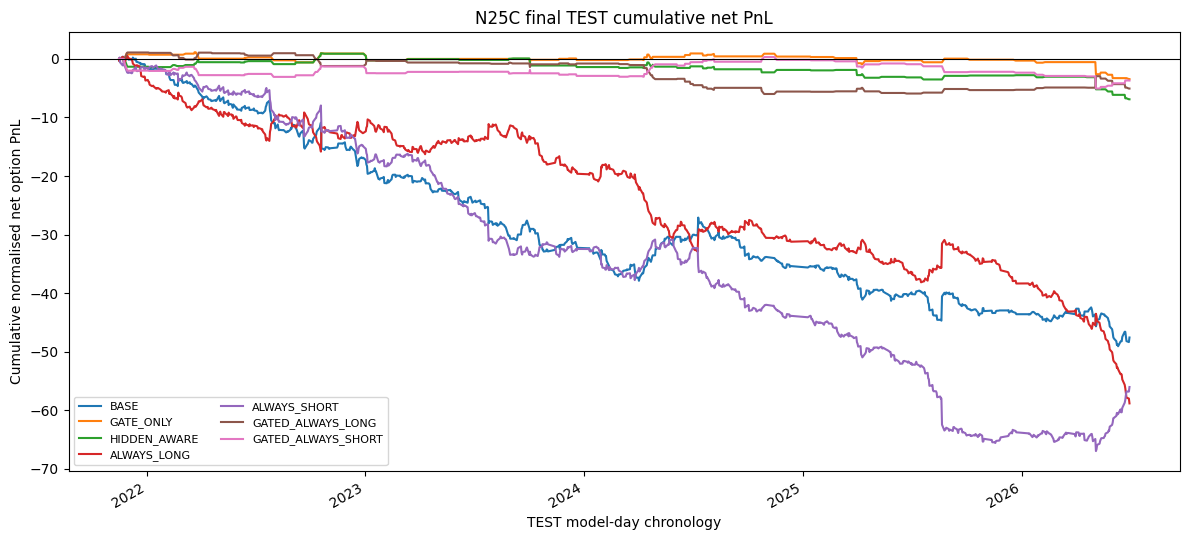

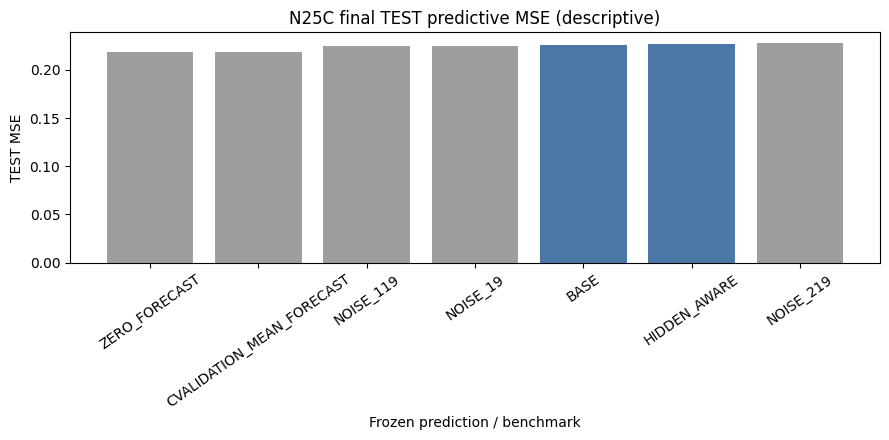

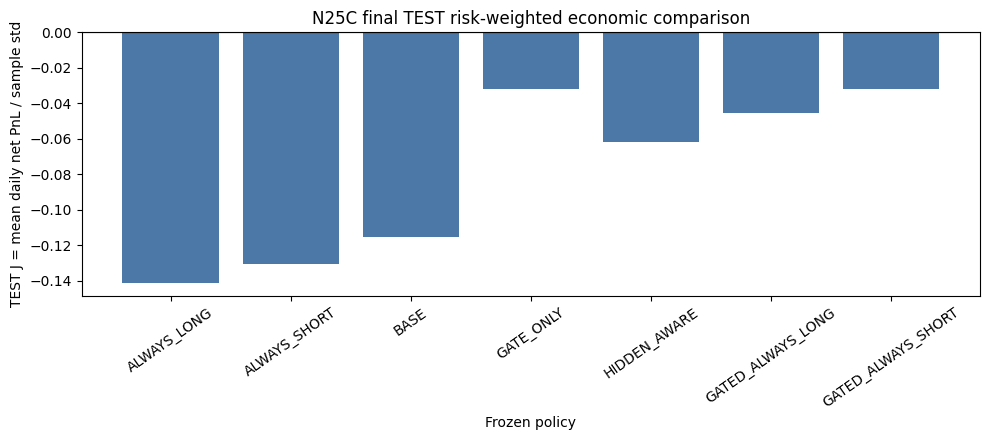

### VALIDATION → TEST stability (descriptive only)

,selected_candidate_id,VALIDATION_J,TEST_J,VALIDATION_cumulative_net_pnl,TEST_cumulative_net_pnl,VALIDATION_trade_count,TEST_trade_count,VALIDATION_MSE,TEST_MSE
0,16,-0.153931,-0.115552,-63.973932,-47.562725,783,784,0.234856,0.225252


### Supporting gate-timing diagnostic

,diagnostic,sample_definition,n_obs,n_gate,n_non_gate,intercept_estimate,gate_coefficient_estimate,HAC_standard_error_lag5,test_statistic,p_value,ci95_lower,ci95_upper,HAC_maxlags
0,supporting inferential diagnostic: BASE trade ...,TEST observations on which frozen BASE action ...,784,59,725,-0.060845,0.002368,0.060761,0.038969,0.968915,-0.116722,0.121458,5


### Supporting incremental hidden-information diagnostic

,diagnostic,n_paired_gated_observations,mean_difference,median_difference,std_difference_ddof_1,coefficient_constant,standard_error_HAC_lag5,test_statistic,p_value,ci95_lower,ci95_upper,HAC_maxlags
0,supporting inferential diagnostic: HIDDEN_AWAR...,74,-0.04654,0.0,0.395247,-0.04654,0.041335,-1.125919,0.2602,-0.127555,0.034475,5


### Final N25C TEST summary

,policy,n_long,n_flat,n_short,n_active_trades,mean_daily_net_pnl,std_daily_net_pnl,cumulative_net_pnl,maximum_drawdown,active_trade_hit_rate,TEST_J
0,FLAT,0,901,0,0,0.000000,0.000000,0.000000,0.000000,NaN,NaN
1,ALWAYS_LONG,901,0,0,901,-0.065275,0.461633,-58.812969,-59.319653,0.327414,-0.141401
2,ALWAYS_SHORT,0,0,901,901,-0.062171,0.475661,-56.015881,-67.193928,0.492786,-0.130704
3,BASE,243,117,541,784,-0.052789,0.456841,-47.562725,-49.565320,0.463010,-0.115552
4,GATE_ONLY,17,842,42,59,-0.003829,0.120731,-3.450149,-4.581431,0.457627,-0.031717
5,HIDDEN_AWARE,25,834,42,67,-0.007652,0.123724,-6.894111,-7.840208,0.432836,-0.061844
6,GATED_ALWAYS_LONG,74,827,0,74,-0.005620,0.123715,-5.063363,-7.087356,0.351351,-0.045425
7,GATED_ALWAYS_SHORT,0,827,74,74,-0.004101,0.129114,-3.694900,-5.384944,0.472973,-0.031762


In [3]:
# Compact required figures.
plot_order = ['BASE','GATE_ONLY','HIDDEN_AWARE','ALWAYS_LONG','ALWAYS_SHORT','GATED_ALWAYS_LONG','GATED_ALWAYS_SHORT']
fig, ax = plt.subplots(figsize=(12,5.5))
for policy in plot_order:
    ax.plot(evalp['decision_model_day'], np.cumsum(realised_pnl(policy_actions[policy])), label=policy, linewidth=1.5)
ax.axhline(0, color='black', linewidth=.8); ax.set_xlabel('TEST model-day chronology'); ax.set_ylabel('Cumulative normalised net option PnL')
ax.set_title('N25C final TEST cumulative net PnL'); ax.legend(ncol=2, fontsize=8); fig.autofmt_xdate(); fig.tight_layout()
fig.savefig(FIGURES / '25C_test_cumulative_net_pnl.png', dpi=180, bbox_inches='tight'); plt.show(); plt.close(fig)

fig, ax = plt.subplots(figsize=(9,4.5))
mse_plot = predictive_metrics.copy()
ax.bar(mse_plot['model'], mse_plot['MSE'], color=['#4C78A8' if x in {'BASE','HIDDEN_AWARE'} else '#9E9E9E' for x in mse_plot['model']])
ax.set_ylabel('TEST MSE'); ax.set_xlabel('Frozen prediction / benchmark'); ax.set_title('N25C final TEST predictive MSE (descriptive)'); ax.tick_params(axis='x', rotation=35); fig.tight_layout()
fig.savefig(FIGURES / '25C_test_predictive_mse_comparison.png', dpi=180, bbox_inches='tight'); plt.show(); plt.close(fig)

fig, ax = plt.subplots(figsize=(10,4.5))
j_plot = economic_metrics.loc[economic_metrics['policy'].ne('FLAT'), ['policy','TEST_J']].copy()
ax.bar(j_plot['policy'], j_plot['TEST_J'], color='#4C78A8'); ax.axhline(0, color='black', linewidth=.8)
ax.set_ylabel('TEST J = mean daily net PnL / sample std'); ax.set_xlabel('Frozen policy'); ax.set_title('N25C final TEST risk-weighted economic comparison'); ax.tick_params(axis='x', rotation=35); fig.tight_layout()
fig.savefig(FIGURES / '25C_test_risk_weighted_J_comparison.png', dpi=180, bbox_inches='tight'); plt.show(); plt.close(fig)

# VALIDATION-to-TEST stability is descriptive; it reads N24C pre-TEST diagnostics only.
candidate_selection = pd.read_csv(PROCESSED / '24C_risk_weighted_candidate_selection.csv')
winner = candidate_selection.loc[candidate_selection['candidate_id'].eq(int(spec_row['selected_candidate_id']))].iloc[0]
pretest_economics = pd.read_csv(PROCESSED / '24C_economic_diagnostics_pretest.csv')
validation_base = pretest_economics.loc[(pretest_economics['stage'].eq('VALIDATION')) & (pretest_economics['policy'].eq('BASE'))].iloc[0]
test_base = economic_metrics.loc[economic_metrics['policy'].eq('BASE')].iloc[0]
test_base_mse = predictive_metrics.loc[predictive_metrics['model'].eq('BASE'), 'MSE'].iloc[0]
stability_summary = pd.DataFrame([{
    'selected_candidate_id':int(spec_row['selected_candidate_id']), 'VALIDATION_J':float(winner['VALIDATION_J']), 'TEST_J':float(test_base['TEST_J']),
    'VALIDATION_cumulative_net_pnl':float(winner['VALIDATION_cumulative_net_pnl']), 'TEST_cumulative_net_pnl':float(test_base['cumulative_net_pnl']),
    'VALIDATION_trade_count':int(winner['VALIDATION_n_trade']), 'TEST_trade_count':int(test_base['n_active_trades']),
    'VALIDATION_MSE':float(winner['VALIDATION_MSE']), 'TEST_MSE':float(test_base_mse)
}])

final_summary = economic_metrics[['policy','n_long','n_flat','n_short','n_active_trades','mean_daily_net_pnl','std_daily_net_pnl','cumulative_net_pnl','maximum_drawdown','active_trade_hit_rate','TEST_J']].copy()
display(Markdown('### VALIDATION → TEST stability (descriptive only)'))
display(stability_summary)
display(Markdown('### Supporting gate-timing diagnostic'))
display(gate_timing_diagnostic)
display(Markdown('### Supporting incremental hidden-information diagnostic'))
display(hidden_incremental_diagnostic)
display(Markdown('### Final N25C TEST summary'))
display(final_summary)


In [4]:
# Export only N25C artifacts; N24C inputs are asserted byte-stable before and after evaluation.
exports = {
    '25C_test_merged_evaluation_panel.csv': evalp,
    '25C_test_target_descriptive_statistics.csv': target_statistics,
    '25C_test_predictive_metrics.csv': predictive_metrics,
    '25C_test_policy_action_counts.csv': policy_action_counts,
    '25C_test_economic_metrics.csv': economic_metrics,
    '25C_test_daily_policy_pnl.csv': daily_policy_pnl,
    '25C_test_gate_timing_diagnostic.csv': gate_timing_diagnostic,
    '25C_test_hidden_incremental_diagnostic.csv': hidden_incremental_diagnostic,
    '25C_validation_test_stability_summary.csv': stability_summary,
    '25C_final_test_summary.csv': final_summary,
}
assert len(exports) == len(set(exports)), 'Duplicate N25C export paths.'
for name, frame in exports.items():
    frame.to_csv(PROCESSED / name, index=False)
manifest_rows = [{'file':name, 'rows':len(frame), 'exists':(PROCESSED/name).exists(), 'nonempty_file':(PROCESSED/name).stat().st_size > 0} for name,frame in exports.items()]
for figure_name in ['25C_test_cumulative_net_pnl.png','25C_test_predictive_mse_comparison.png','25C_test_risk_weighted_J_comparison.png']:
    fp = FIGURES / figure_name
    manifest_rows.append({'file':f'figures/{figure_name}', 'rows':np.nan, 'exists':fp.exists(), 'nonempty_file':fp.exists() and fp.stat().st_size > 0})
export_manifest = pd.DataFrame(manifest_rows)
export_manifest.to_csv(PROCESSED / '25C_export_manifest.csv', index=False)
assert export_manifest['exists'].all() and export_manifest['nonempty_file'].all()
assert n24c_hashes_before == {p.name: sha256(p) for p in [handoff_path, spec_path, refit_path, availability_path, pretest_path]}, 'Frozen N24C files changed after TEST outcomes opened.'
assert figure_hashes_before == {p.name: sha256(p) for p in figure_paths}, 'A required accepted N25C figure changed during the diagnostic-only correction.'

def assert_frame_invariant(before, after, label):
    assert list(before.columns) == list(after.columns), f'{label}: schema changed.'
    assert len(before) == len(after), f'{label}: row count changed.'
    for column in before.columns:
        old, new = before[column], after[column]
        if pd.api.types.is_numeric_dtype(old) and pd.api.types.is_numeric_dtype(new):
            assert np.allclose(old.to_numpy(float), new.to_numpy(float), rtol=0, atol=1e-12, equal_nan=True), f'{label}: numerical change in {column}.'
        else:
            assert old.fillna('__NA__').astype(str).equals(new.fillna('__NA__').astype(str)), f'{label}: value change in {column}.'

assert_frame_invariant(primary_reference['predictive'], predictive_metrics, 'Primary predictive metrics')
assert_frame_invariant(primary_reference['economics'], economic_metrics, 'Primary economic metrics')
assert_frame_invariant(primary_reference['actions'], policy_action_counts, 'Policy action counts')
assert_frame_invariant(primary_reference['hidden_incremental'], hidden_incremental_diagnostic, 'Hidden-incremental diagnostic')
print('N25C primary-invariance audit: PASS')

def metric(policy, column):
    return economic_metrics.loc[economic_metrics['policy'].eq(policy), column].iloc[0]
def pred(model, column):
    return predictive_metrics.loc[predictive_metrics['model'].eq(model), column].iloc[0]
print('FINAL N25C TEST PREDICTIVE EVALUATION')
for label in ['ZERO_FORECAST','CVALIDATION_MEAN_FORECAST','BASE','HIDDEN_AWARE']:
    print(f'{label} MSE: {pred(label, "MSE"):.12g}')
print(f'BASE correlation: {pred("BASE", "correlation"):.12g}')
print(f'HIDDEN_AWARE correlation: {pred("HIDDEN_AWARE", "correlation"):.12g}')
print('\nFINAL N25C TEST ECONOMIC EVALUATION')
for policy in ['BASE','GATE_ONLY','HIDDEN_AWARE','ALWAYS_LONG','ALWAYS_SHORT','GATED_ALWAYS_LONG','GATED_ALWAYS_SHORT','FLAT']:
    print(f'{policy}: cumulative net PnL = {metric(policy, "cumulative_net_pnl"):.12g}; TEST J = {metric(policy, "TEST_J")}')
print(f'J_HIDDEN_AWARE - J_GATE_ONLY = {metric("HIDDEN_AWARE", "TEST_J") - metric("GATE_ONLY", "TEST_J"):.12g}')
best_gated_constant = economic_metrics.loc[economic_metrics['policy'].isin(['GATED_ALWAYS_LONG','GATED_ALWAYS_SHORT'])].sort_values('TEST_J', ascending=False).iloc[0]
print('\nN25C FINAL TEST FREEZE')
for line in ['N24C specification changed after TEST outcomes opened: NO','Hyperparameters changed: NO','Features changed: NO','Gate changed: NO','Action rule changed: NO','Transaction costs changed: NO','Support rule changed: NO','TEST rows excluded because of poor performance: NO','Additional model search after TEST: NO']:
    print(line)
closure = pd.DataFrame([{
    'selected_N24C_candidate_id':int(spec_row['selected_candidate_id']), 'frozen_hyperparameters':str(params), 'N24C_VALIDATION_J':float(winner['VALIDATION_J']),
    'TEST_rows':len(evalp), 'TEST_gate_rows':int(evalp['G_t'].sum()), 'TEST_target_mean':float(np.mean(target)), 'TEST_target_median':float(np.median(target)),
    'ZERO_TEST_MSE':float(pred('ZERO_FORECAST','MSE')), 'BASE_TEST_MSE':float(pred('BASE','MSE')), 'HIDDEN_AWARE_TEST_MSE':float(pred('HIDDEN_AWARE','MSE')),
    'BASE_TEST_J':float(metric('BASE','TEST_J')), 'GATE_ONLY_TEST_J':float(metric('GATE_ONLY','TEST_J')), 'HIDDEN_AWARE_TEST_J':float(metric('HIDDEN_AWARE','TEST_J')),
    'BASE_cumulative_net_pnl':float(metric('BASE','cumulative_net_pnl')), 'GATE_ONLY_cumulative_net_pnl':float(metric('GATE_ONLY','cumulative_net_pnl')),
    'HIDDEN_AWARE_cumulative_net_pnl':float(metric('HIDDEN_AWARE','cumulative_net_pnl')), 'best_constant_direction_gated_control':best_gated_constant['policy'],
    'gate_timing_sample':'BASE active TEST trades only', 'gate_timing_n_obs':int(gate_timing_diagnostic.loc[0,'n_obs']),
    'gate_timing_n_gate':int(gate_timing_diagnostic.loc[0,'n_gate']), 'gate_timing_n_non_gate':int(gate_timing_diagnostic.loc[0,'n_non_gate']),
    'gate_timing_estimate':float(gate_timing_diagnostic.loc[0,'gate_coefficient_estimate']), 'gate_timing_p_value':float(gate_timing_diagnostic.loc[0,'p_value']),
    'hidden_incremental_estimate':float(hidden_incremental_diagnostic.loc[0,'coefficient_constant']), 'hidden_incremental_p_value':float(hidden_incremental_diagnostic.loc[0,'p_value']),
    'post_TEST_design_changes':'NO', 'execution_errors':0
}])
display(Markdown('### Final closure'))
display(closure)
print('\nN25C TEST INTERPRETATION')
if metric('GATE_ONLY', 'TEST_J') > metric('HIDDEN_AWARE', 'TEST_J'):
    print('Hidden-state timing is more useful than the additional hidden-state characteristics under the frozen risk-weighted application.')
else:
    print('Under the frozen risk-weighted-selected specification, hidden-state characteristics improve TEST economic performance relative to timing alone.')
if metric('BASE', 'TEST_J') < 0 and metric('GATE_ONLY', 'TEST_J') < 0 and metric('HIDDEN_AWARE', 'TEST_J') < 0:
    print('Risk-weighted pre-TEST model selection does not rescue the economic application on final TEST.')
if float(hidden_incremental_diagnostic.loc[0, 'p_value']) >= .05:
    print('No robust incremental effect is detected at the available sample size; this does not establish that the true effect is zero.')
if float(gate_timing_diagnostic.loc[0, 'p_value']) >= .05:
    print('No statistically robust difference in BASE trade outcomes between gate and non-gate dates is detected at the available sample size.')
print('The supporting gate-timing regression is restricted to observations on which the frozen BASE policy takes an active long or short position. It therefore asks whether BASE trade outcomes differ between hidden-gate and non-gate dates, rather than mechanically comparing traded and flat observations.')
print('\nN25C FINAL FREEZE VERIFICATION')
print('Gate-timing diagnostic restricted to BASE active trades: YES')
print(f'Gate-timing diagnostic n: {int(gate_timing_diagnostic.loc[0, "n_obs"])}')
print(f'Gate / non-gate BASE trades: {int(gate_timing_diagnostic.loc[0, "n_gate"])} / {int(gate_timing_diagnostic.loc[0, "n_non_gate"])}')
print(f'Gate coefficient / HAC SE / p-value: {gate_timing_diagnostic.loc[0, "gate_coefficient_estimate"]:.12g} / {gate_timing_diagnostic.loc[0, "HAC_standard_error_lag5"]:.12g} / {gate_timing_diagnostic.loc[0, "p_value"]:.12g}')
print(f'Gate coefficient 95% CI: [{gate_timing_diagnostic.loc[0, "ci95_lower"]:.12g}, {gate_timing_diagnostic.loc[0, "ci95_upper"]:.12g}]')
for line in ['Primary TEST predictions changed: NO','Primary TEST actions changed: NO','Primary predictive metrics changed: NO','Primary economic metrics changed: NO','Hidden-incremental diagnostic changed: NO','Hyperparameters changed: NO','Features changed: NO','Gate changed: NO','Action rule changed: NO','Transaction costs changed: NO','Support rule changed: NO','Additional model search performed: NO','Post-TEST optimisation performed: NO','Execution errors: 0']:
    print(line)
print('N25C final closure: PASS')


N25C primary-invariance audit: PASS
FINAL N25C TEST PREDICTIVE EVALUATION
ZERO_FORECAST MSE: 0.21805187374
CVALIDATION_MEAN_FORECAST MSE: 0.218102752943
BASE MSE: 0.225252156398
HIDDEN_AWARE MSE: 0.226423402613
BASE correlation: -0.00892925700061
HIDDEN_AWARE correlation: -0.00431490855312

FINAL N25C TEST ECONOMIC EVALUATION
BASE: cumulative net PnL = -47.5627246478; TEST J = -0.11555176110769384
GATE_ONLY: cumulative net PnL = -3.45014901358; TEST J = -0.031717039073460074
HIDDEN_AWARE: cumulative net PnL = -6.89411070295; TEST J = -0.061844495426763915
ALWAYS_LONG: cumulative net PnL = -58.8129690714; TEST J = -0.14140064218421466
ALWAYS_SHORT: cumulative net PnL = -56.0158805214; TEST J = -0.1307040352062983
GATED_ALWAYS_LONG: cumulative net PnL = -5.06336297355; TEST J = -0.045424524168270974
GATED_ALWAYS_SHORT: cumulative net PnL = -3.69489995531; TEST J = -0.031761842618279856
FLAT: cumulative net PnL = 0; TEST J = nan
J_HIDDEN_AWARE - J_GATE_ONLY = -0.0301274563533

N25C FINAL 

### Final closure

,selected_N24C_candidate_id,frozen_hyperparameters,N24C_VALIDATION_J,TEST_rows,TEST_gate_rows,TEST_target_mean,TEST_target_median,ZERO_TEST_MSE,BASE_TEST_MSE,HIDDEN_AWARE_TEST_MSE,...,gate_timing_sample,gate_timing_n_obs,gate_timing_n_gate,gate_timing_n_non_gate,gate_timing_estimate,gate_timing_p_value,hidden_incremental_estimate,hidden_incremental_p_value,post_TEST_design_changes,execution_errors
0,16,"{'loss': 'squared_error', 'subsample': 1.0, 'r...",-0.153931,901,74,-0.001552,-0.062881,0.218052,0.225252,0.226423,...,BASE active TEST trades only,784,59,725,0.002368,0.968915,-0.04654,0.2602,NO,0



N25C TEST INTERPRETATION
Hidden-state timing is more useful than the additional hidden-state characteristics under the frozen risk-weighted application.
Risk-weighted pre-TEST model selection does not rescue the economic application on final TEST.
No robust incremental effect is detected at the available sample size; this does not establish that the true effect is zero.
No statistically robust difference in BASE trade outcomes between gate and non-gate dates is detected at the available sample size.
The supporting gate-timing regression is restricted to observations on which the frozen BASE policy takes an active long or short position. It therefore asks whether BASE trade outcomes differ between hidden-gate and non-gate dates, rather than mechanically comparing traded and flat observations.

N25C FINAL FREEZE VERIFICATION
Gate-timing diagnostic restricted to BASE active trades: YES
Gate-timing diagnostic n: 784
Gate / non-gate BASE trades: 59 / 725
Gate coefficient / HAC SE / p-value